### Dataset Preprocessing

##### 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split

##### 2. Load Dataset

In [3]:
# load dataset
dataset = load_dataset("shainar/BEAD", "Full_Annotations", split="full")
dataset = dataset.remove_columns(['biased_words', 'dimension', 'aspect', 'identity_mention'])
print(dataset)

Dataset({
    features: ['text', 'label', 'sentiment', 'toxic'],
    num_rows: 3674927
})


##### 3. Preprocess Dataset

In [4]:
# function to batch clean text
def clean_batch(batch):
    import re
    import emoji

    # regex patterns
    RE_HTML = re.compile(r'<.*?>|&([a-z0-9]+|#[0-9]{1,6}|#x[0-9a-f]{1,6});')
    RE_URL = re.compile(r'https?://\S+|www\.\S+')
    RE_SPECIAL = re.compile(r'[^a-z0-9\s.,!?@#$*%+-]')
    RE_SPACES = re.compile(r'\s+')

    cleaned_texts = []
    for text in batch['text']:
        if text is None:
            text = ""

        text = text.lower()
        text = emoji.demojize(text, delimiters=(" ", " ")).replace(":", "").replace("_", " ")
        text = RE_HTML.sub('', text)
        text = RE_URL.sub('', text)
        text = RE_SPECIAL.sub('', text)
        text = RE_SPACES.sub(' ', text).strip()
        
        cleaned_texts.append(text)
    
    return {"text": cleaned_texts}

In [5]:
# clean dataset text
NUM_PROC = os.cpu_count()

dataset = dataset.map(
    clean_batch, 
    batched=True, 
    batch_size=1000, 
    num_proc=NUM_PROC
)

# drop empty text rows
dataset = dataset.filter(lambda x: x['text'] is not None and len(x['text']) > 0)

In [6]:
# convert to pandas dataframe
df = dataset.to_pandas()
df.rename(columns={"label": "bias"}, inplace=True)
print(f"Current Shape: {df.shape}")

Current Shape: (3674663, 4)


In [7]:
# drop duplicate rows
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Dropped {before - after} rows.")
print(f"Current Shape: {df.shape}")

Dropped 12152 rows.
Current Shape: (3662511, 4)


In [8]:
# text lengths
df["text_length"] = df["text"].str.len()
desc = df["text_length"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print(desc)

count    3.662511e+06
mean     2.057039e+02
std      2.827018e+02
min      1.000000e+00
25%      5.700000e+01
50%      1.060000e+02
75%      2.360000e+02
90%      5.330000e+02
95%      7.980000e+02
99%      9.910000e+02
max      3.233200e+04
Name: text_length, dtype: float64


In [9]:
# vectorized filtering based on length
mask = (df["text_length"] >= 10) & (df["text_length"] <= 512)
dropped_count = len(df) - mask.sum()
df = df[mask].reset_index(drop=True)

print(f"Dropped {dropped_count} rows.")
print(f"Current Shape: {df.shape}")

Dropped 396384 rows.
Current Shape: (3266127, 5)


##### 4. Label Encoding

In [10]:
print(df.head())

                                                text             bias  \
0  where will this leave the kids??? that my frie...  Slightly Biased   
1  i had a feeling of impending doom then hear ab...    Highly Biased   
2                                  i no feel good ..          Neutral   
3  back in hotlanta for a about a week, then off ...  Slightly Biased   
4  kids toys stamping stuff cleaned up... next ki...          Neutral   

  sentiment  toxic  text_length  
0  Negative    0.0           78  
1  Negative    1.0           73  
2  Positive    0.0           17  
3  Negative    0.0          133  
4   Neutral    1.0           99  


In [11]:
mappings = {}

for col, order in [
    ('bias', ['Neutral', 'Slightly Biased', 'Highly Biased']),
    ('sentiment', ['Negative', 'Neutral', 'Positive']),
]:
    df[col] = pd.Categorical(df[col], categories=order, ordered=True)
    mappings[col] = dict(enumerate(df[col].cat.categories))
    df[col] = df[col].cat.codes

df['toxic'] = df['toxic'].astype(int)

print(f"Mappings: {mappings}")

Mappings: {'bias': {0: 'Neutral', 1: 'Slightly Biased', 2: 'Highly Biased'}, 'sentiment': {0: 'Negative', 1: 'Neutral', 2: 'Positive'}}


In [12]:
print(df.head())

                                                text  bias  sentiment  toxic  \
0  where will this leave the kids??? that my frie...     1          0      0   
1  i had a feeling of impending doom then hear ab...     2          0      1   
2                                  i no feel good ..     0          2      0   
3  back in hotlanta for a about a week, then off ...     1          0      0   
4  kids toys stamping stuff cleaned up... next ki...     0          1      1   

   text_length  
0           78  
1           73  
2           17  
3          133  
4           99  


##### 5. Train/Val/Test Split

In [13]:
# combined label for stratification
df["strat_label"] = (
    df["bias"].astype(str) + "_" +
    df["sentiment"].astype(str) + "_" +
    df["toxic"].astype(str)
)
print(df["strat_label"].value_counts())

strat_label
0_2_0    893115
0_1_0    495233
1_0_0    329199
2_0_1    307954
0_2_1    246783
1_0_1    215650
2_0_0    193945
0_1_1    184570
1_2_0    179434
1_2_1    124846
1_1_0     35647
1_1_1     34905
2_2_1     11922
2_2_0     10914
2_1_1      1183
2_1_0       827
Name: count, dtype: int64


In [14]:
# train-test split
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["strat_label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["strat_label"]
)

print(len(train_df), len(val_df), len(test_df))

2286288 489919 489920


In [15]:
train_df = train_df.drop(columns=["strat_label"])
val_df   = val_df.drop(columns=["strat_label"])
test_df  = test_df.drop(columns=["strat_label"])

##### 6. Train Set Class Rebalancing

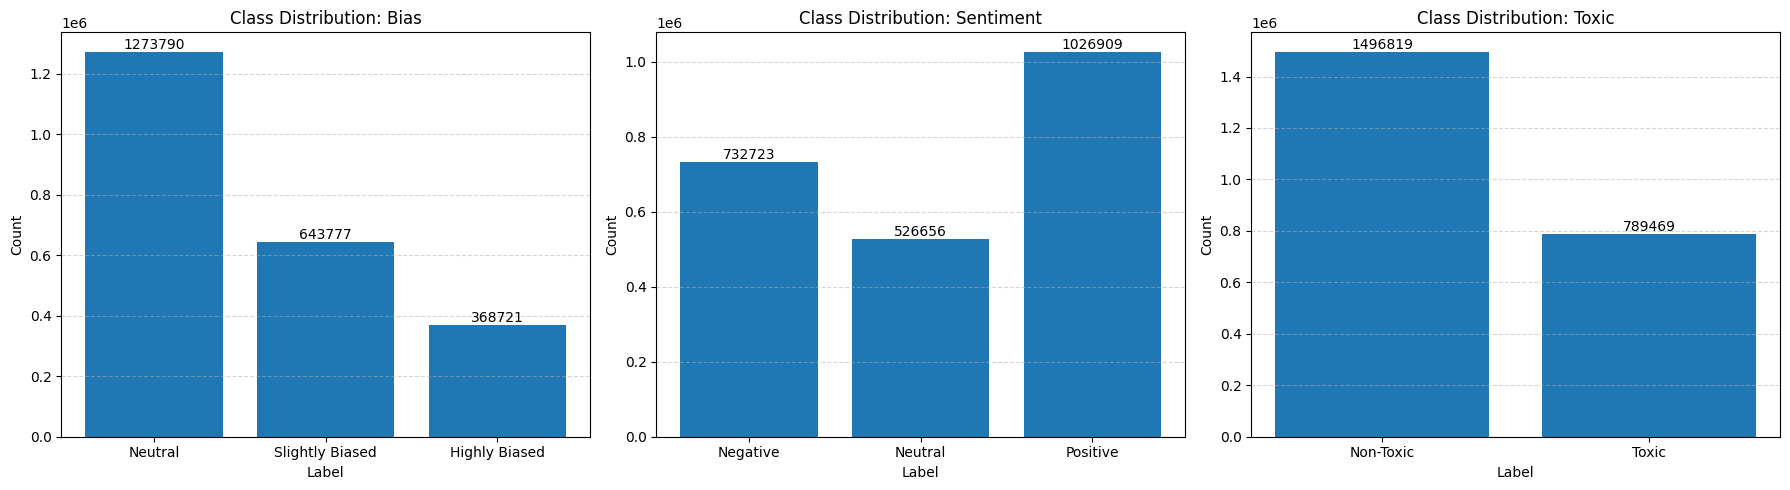

In [16]:
plot_config = [
    ("bias", ["Neutral", "Slightly Biased", "Highly Biased"]),
    ("sentiment", ["Negative", "Neutral", "Positive"]),
    ("toxic", ["Non-Toxic", "Toxic"])
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for (col, labels), ax in zip(plot_config, axes):
    counts = train_df[col].value_counts().sort_index()
    ax.bar(labels, counts.values)
    ax.set_title(f'Class Distribution: {col.title()}')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [17]:
# target class ratios
weights = {
    "bias": {0: 0.50, 1: 0.30, 2: 0.20},
    "sentiment": {0: 0.35, 1: 0.30, 2: 0.35},
    "toxic": {0: 0.60, 1: 0.40}
}
base_target_size = len(train_df)

train_df['joint_group'] = list(zip(train_df['bias'], train_df['toxic'], train_df['sentiment']))
groups = train_df.groupby('joint_group')
final_indices = []

for label, group_indices in groups.indices.items():
    b, t, s = label
    
    # calculate joint weight
    w = weights['bias'][b] * weights['toxic'][t] * weights['sentiment'][s]
    target_n = int(base_target_size * w)
    current_n = len(group_indices)
    
    if target_n == 0:
        continue
        
    if current_n >= target_n:
        # downsample: randomly select n indices without replacement
        selected = np.random.choice(group_indices, target_n, replace=False)
    else:
        # upsample: select all, then random choice with replacement for the remainder
        selected = np.concatenate([
            group_indices,
            np.random.choice(group_indices, target_n - current_n, replace=True)
        ])
        
    final_indices.append(selected)

# build final dataframe
all_indices = np.concatenate(final_indices)
balanced_train_df = train_df.iloc[all_indices].reset_index(drop=True)

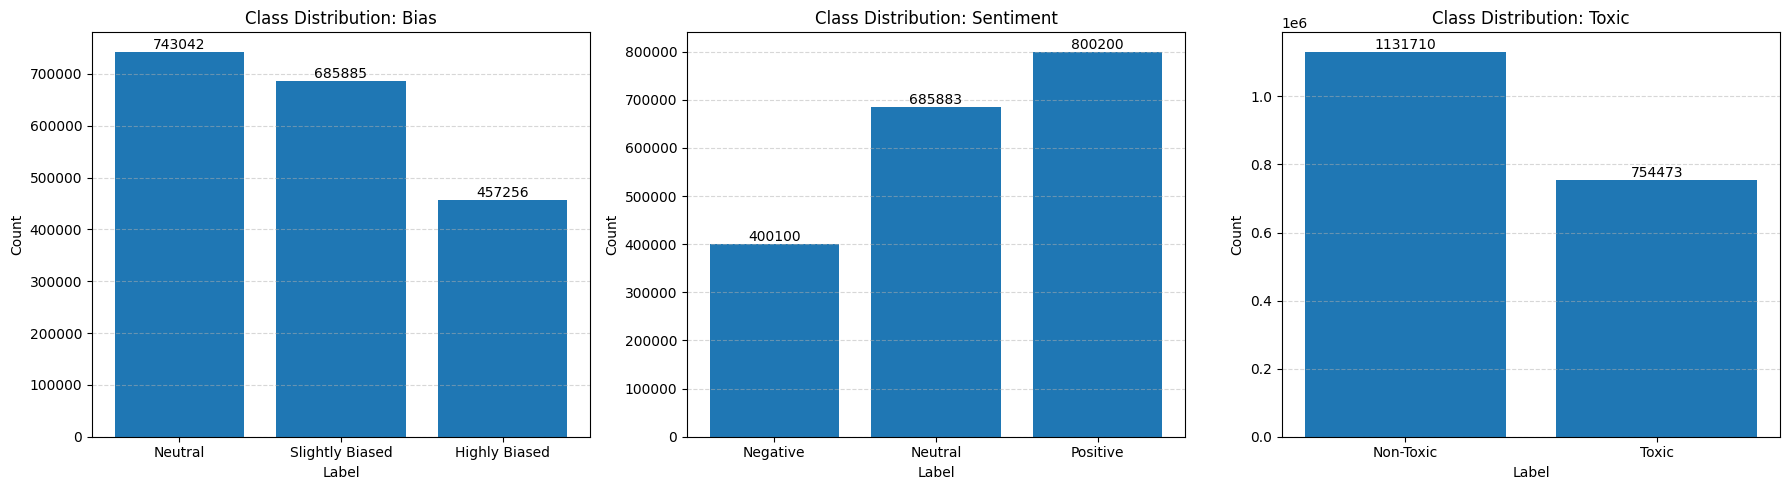

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for (col, labels), ax in zip(plot_config, axes):
    counts = balanced_train_df[col].value_counts().sort_index()
    ax.bar(labels, counts.values)
    ax.set_title(f'Class Distribution: {col.title()}')
    ax.set_xlabel('Label')
    ax.set_ylabel('Count')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [19]:
print("Old Distributions:")
print(f"Original Size: {len(train_df)}")
print(train_df['bias'].value_counts(normalize=True))
print(train_df['sentiment'].value_counts(normalize=True))
print(train_df['toxic'].value_counts(normalize=True))

print("\nNew Distributions:")
print(f"Balanced Size: {len(balanced_train_df)}")
print(balanced_train_df['bias'].value_counts(normalize=True))
print(balanced_train_df['sentiment'].value_counts(normalize=True))
print(balanced_train_df['toxic'].value_counts(normalize=True))

Old Distributions:
Original Size: 2286288
bias
0    0.557143
1    0.281582
2    0.161275
Name: proportion, dtype: float64
sentiment
2    0.449160
0    0.320486
1    0.230354
Name: proportion, dtype: float64
toxic
0    0.654694
1    0.345306
Name: proportion, dtype: float64

New Distributions:
Balanced Size: 1886183
bias
0    0.393940
1    0.363637
2    0.242424
Name: proportion, dtype: float64
sentiment
2    0.424243
1    0.363635
0    0.212122
Name: proportion, dtype: float64
toxic
0    0.6
1    0.4
Name: proportion, dtype: float64


##### 7. Save to Parquet

In [20]:
balanced_train_df.to_parquet("train_set.parquet", index=False)
val_df.to_parquet("val_set.parquet", index=False)
test_df.to_parquet("test_set.parquet", index=False)
print("All files saved.")

All files saved.
